In [1]:
%load_ext autoreload
%autoreload 2

from src.robin.scraping.entities import DataLoader, SupplySaver
from src.services_generator.entities import ServiceGenerator

from pathlib import Path

In [5]:
import_path = '../data/renfe'
trips_path = f'{import_path}/stop_times/stopTimes_MADRI_BARCE_2023-06-01_2023-06-02.csv'

data_loader = DataLoader(trips_path, renfe_stations_path='../data/renfe/renfe_stations.csv')
data_loader.show_metadata()
data_loader.build_supply_entities()
print(data_loader.services[0])

services = data_loader.services

Origin:MADRI - Destination:BARCE
Since: 2023-06-01, Until: 2023-06-02
Service id: 06301_01-06-2023-06.15 
	Date of service: 2023-06-01 
	Stops: ['60000', '71801'] 
	Line times (relative): [(0, 0), (150, 150)] 
	Line times (absolute): [('06:15', '06:15'), ('08:45', '08:45')] 
	Train Service Provider: [1, Renfe, ['1']] 
	Time Slot: [37510, 6:15:00, 6:25:00, 6:20:00, 0:10:00] 
	Rolling Stock: [1, S-114, {1: 250, 2: 50}] 
	Prices: 
		('60000', '71801'): {Basico: 15.0} 
	Tickets sold (seats): {Basico: 0} 
	Tickets sold (hard type): {1: 0, 2: 0} 
	Tickets sold per each pair (seats): {('60000', '71801'): {Basico: 0}} 
	Tickets sold per each pair (hard type): {('60000', '71801'): {1: 0}} 
	Capacity constraints: None 


In [7]:
SupplySaver(services).to_yaml(filename='supply_data_gen.yml', save_path='../configs/thesis/')

In [10]:
# Load yml

import yaml

with open('../configs/thesis/supply_data_gen.yml', 'r') as file:
    data = yaml.load(file, Loader=yaml.CSafeLoader)
    
data.pop('service')

data

{'stations': [{'id': '04307',
   'name': 'Figueres Vilafant',
   'city': 'Figueres',
   'short_name': 'FIG',
   'coordinates': {'latitude': 42.264771, 'longitude': 2.943547}},
  {'id': '04040',
   'name': 'Zaragoza-Delicias',
   'city': 'Zaragoza',
   'short_name': 'ZAR',
   'coordinates': {'latitude': 41.658649, 'longitude': -0.911615}},
  {'id': '71801',
   'name': 'Barcelona-Sants',
   'city': 'Barcelona',
   'short_name': 'BAR',
   'coordinates': {'latitude': 41.37922, 'longitude': 2.140624}},
  {'id': '70200',
   'name': 'Guadalajara',
   'city': 'Guadalajara',
   'short_name': 'GUA',
   'coordinates': {'latitude': 40.6441032, 'longitude': -3.1822298}},
  {'id': '60000',
   'name': 'Madrid-Puerta de Atocha',
   'city': 'Madrid',
   'short_name': 'MAD',
   'coordinates': {'latitude': 40.406442, 'longitude': -3.690886}},
  {'id': '78400',
   'name': 'Lleida',
   'city': 'Lleida',
   'short_name': 'LLE',
   'coordinates': {'latitude': 41.620696, 'longitude': 0.632669}},
  {'id': '793

In [12]:
time_slots = data['timeSlot']
time_slots

[{'id': '51010', 'start': '8:30:00', 'end': '8:40:00'},
 {'id': '54010', 'start': '9:00:00', 'end': '9:10:00'},
 {'id': '69010', 'start': '11:30:00', 'end': '11:40:00'},
 {'id': '102010', 'start': '17:00:00', 'end': '17:10:00'},
 {'id': '48010', 'start': '8:00:00', 'end': '8:10:00'},
 {'id': '63010', 'start': '10:30:00', 'end': '10:40:00'},
 {'id': '105010', 'start': '17:30:00', 'end': '17:40:00'},
 {'id': '37510', 'start': '6:15:00', 'end': '6:25:00'},
 {'id': '111010', 'start': '18:30:00', 'end': '18:40:00'},
 {'id': '39010', 'start': '6:30:00', 'end': '6:40:00'},
 {'id': '108010', 'start': '18:00:00', 'end': '18:10:00'},
 {'id': '42010', 'start': '7:00:00', 'end': '7:10:00'},
 {'id': '87010', 'start': '14:30:00', 'end': '14:40:00'},
 {'id': '120010', 'start': '20:00:00', 'end': '20:10:00'},
 {'id': '124010', 'start': '20:40:00', 'end': '20:50:00'},
 {'id': '93010', 'start': '15:30:00', 'end': '15:40:00'},
 {'id': '117010', 'start': '19:30:00', 'end': '19:40:00'},
 {'id': '127010', '

In [37]:
import numpy as np

np.random.seed(1)

train_probs = {0: 0.01,
               1: 0.01,
               2: 0.01,
               3: 0.01,
               4: 0.01,
               5: 0.02,
               6: 0.04,
               7: 0.05,
               8: 0.06,
               9: 0.06,
               10: 0.05,
               11: 0.04,
               12: 0.05,
               13: 0.06,
               14: 0.06,
               15: 0.06,
               16: 0.06,
               17: 0.06,
               18: 0.06,
               19: 0.06,
               20: 0.06,
               21: 0.05,
               22: 0.03,
               23: 0.02}

In [38]:
sum(train_probs.values())

1.0000000000000004

<BarContainer object of 24 artists>

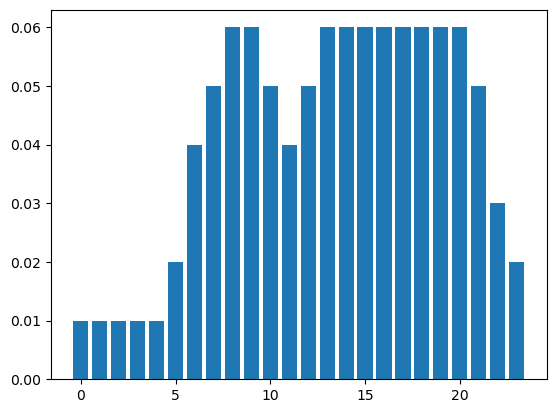

In [39]:
import matplotlib.pyplot as plt

plt.bar(train_probs.keys(), train_probs.values())

In [43]:
from scipy.stats import rv_discrete

distrib = rv_discrete(values=(range(0, 24), list(train_probs.values())), seed=1)

dts = distrib.rvs(size=50)

dts

array([12, 18,  0, 10,  7,  6,  8, 11, 12, 14, 12, 17,  8, 20,  2, 17, 12,
       15,  7,  8, 19, 22, 10, 17, 20, 20,  6,  3,  8, 20,  6, 13, 22, 14,
       17, 10, 17, 19,  1, 18, 23, 18, 10, 19,  6, 13, 21, 10, 10,  7])

In [ ]:
np.random.choice(range(0, 24), size=1000, p=train_probs.values())

In [6]:
supply_config_path = Path("../configs/service_generator/config.yml")

r = ServiceGenerator(supply_config_path=supply_config_path)

In [7]:
config_path = Path("../configs/service_generator_config.yml")

services = r.generate(file_name=Path("../data/gen_v2.yml"),
                      path_config=config_path,
                      n_services=5,
                      seed=1)

In [9]:
for s in services:
    print("HEADER")
    print(s)
    print()
    

HEADER
Service id: 03612_2024-06-25-20.48 
	Date of service: 2024-06-25 
	Stops: ['60000', '71801'] 
	Line times (relative): [(0.0, 0.0), (150.0, 150.0)] 
	Line times (absolute): [('20:48', '20:48'), ('23:18', '23:18')] 
	Train Service Provider: [1, Renfe AVE, ['11', '12', '13']] 
	Time Slot: [74880, 20:48:00, 20:58:00, 20:53:00, 0:10:00] 
	Rolling Stock: [12, AVE RS2, {1: 250, 2: 50}] 
	Prices: 
		('60000', '71801'): {Turista: '52.64', Turista Plus: '63.17', Premium: '84.22'} 
	Tickets sold (seats): {Turista: 0, Premium: 0, Turista Plus: 0} 
	Tickets sold (hard type): {1: 0, 2: 0} 
	Tickets sold per each pair (seats): {('60000', '71801'): {Turista: 0, Premium: 0, Turista Plus: 0}} 
	Tickets sold per each pair (hard type): {('60000', '71801'): {1: 0, 2: 0}} 
	Capacity constraints: None 


HEADER
Service id: 03612_2024-06-25-13.41 
	Date of service: 2024-06-25 
	Stops: ['60000', '71801'] 
	Line times (relative): [(0.0, 0.0), (150.0, 150.0)] 
	Line times (absolute): [('13:41', '13:41'), 

In [5]:
print(services)

[<src.robin.supply.entities.Service object at 0x107148410>, <src.robin.supply.entities.Service object at 0x1373480d0>, <src.robin.supply.entities.Service object at 0x133a5aa10>, <src.robin.supply.entities.Service object at 0x133a5f390>, <src.robin.supply.entities.Service object at 0x1335c5c50>]
